In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Download the Iris dataset if not already present from a reliable source
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data -O iris.csv

# Load the dataset
df = pd.read_csv('iris.csv', header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])

print("1. Displaying the first five records of the dataset:")
display(df.head())

--2026-09-30 04:18:50--  https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘iris.csv’

iris.csv                [ <=>                ]   4.44K  --.-KB/s    in 0s      

2026-09-30 04:18:50 (43.1 MB/s) - ‘iris.csv’ saved [4551]

1. Displaying the first five records of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### a) Exploratory Data Analysis (EDA)

In [ ]:
print("\n2. Checking and displaying missing values:")
display(df.isnull().sum())


2. Checking and displaying missing values:


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
print("\n3. Displaying descriptive statistics of the numerical attributes:")
display(df.describe())


3. Displaying descriptive statistics of the numerical attributes:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



4. Displaying the distribution of the Species classes:


,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


/tmp/ipykernel_5068/1346497492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='viridis')


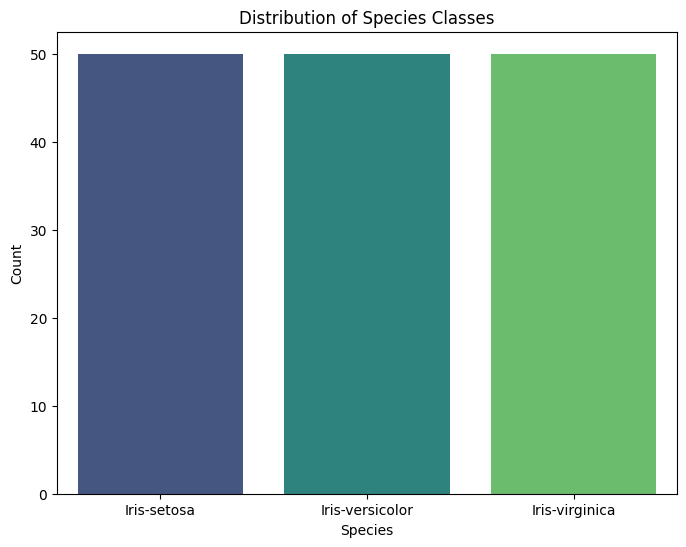

In [ ]:
print("\n4. Displaying the distribution of the Species classes:")
species_distribution = df['species'].value_counts()
display(species_distribution)

plt.figure(figsize=(8, 6))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Distribution of Species Classes')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

### b) Decision Tree Classification

In [ ]:
print("1. Preprocessing the dataset and separating features and target variable:")

X = df.drop('species', axis=1) # Features, dropping 'species'
y = df['species'] # Target variable

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
display(X.head())
display(y.head())

1. Preprocessing the dataset and separating features and target variable:
Features (X) shape: (150, 4)
Target (y) shape: (150,)


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [ ]:
print("\n2. Splitting the dataset into 80% training and 20% testing data:")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")


2. Splitting the dataset into 80% training and 20% testing data:
Training set size: 120 samples
Testing set size: 30 samples


In [ ]:
print("\n3. Implementing a Decision Tree Classifier with a specified maximum depth (e.g., 3):")

# Create a Decision Tree Classifier with max_depth=3
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")


3. Implementing a Decision Tree Classifier with a specified maximum depth (e.g., 3):
Decision Tree Classifier trained successfully!


In [ ]:
print("\n4. Predicting the species of the test data and calculating the classification accuracy:")

y_pred = dtc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Predicted species for test data: {y_pred[:5]}...")
print(f"Classification Accuracy: {accuracy:.4f}")


4. Predicting the species of the test data and calculating the classification accuracy:
Predicted species for test data: ['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor']...
Classification Accuracy: 1.0000



5. Plotting and displaying the resulting Decision Tree:


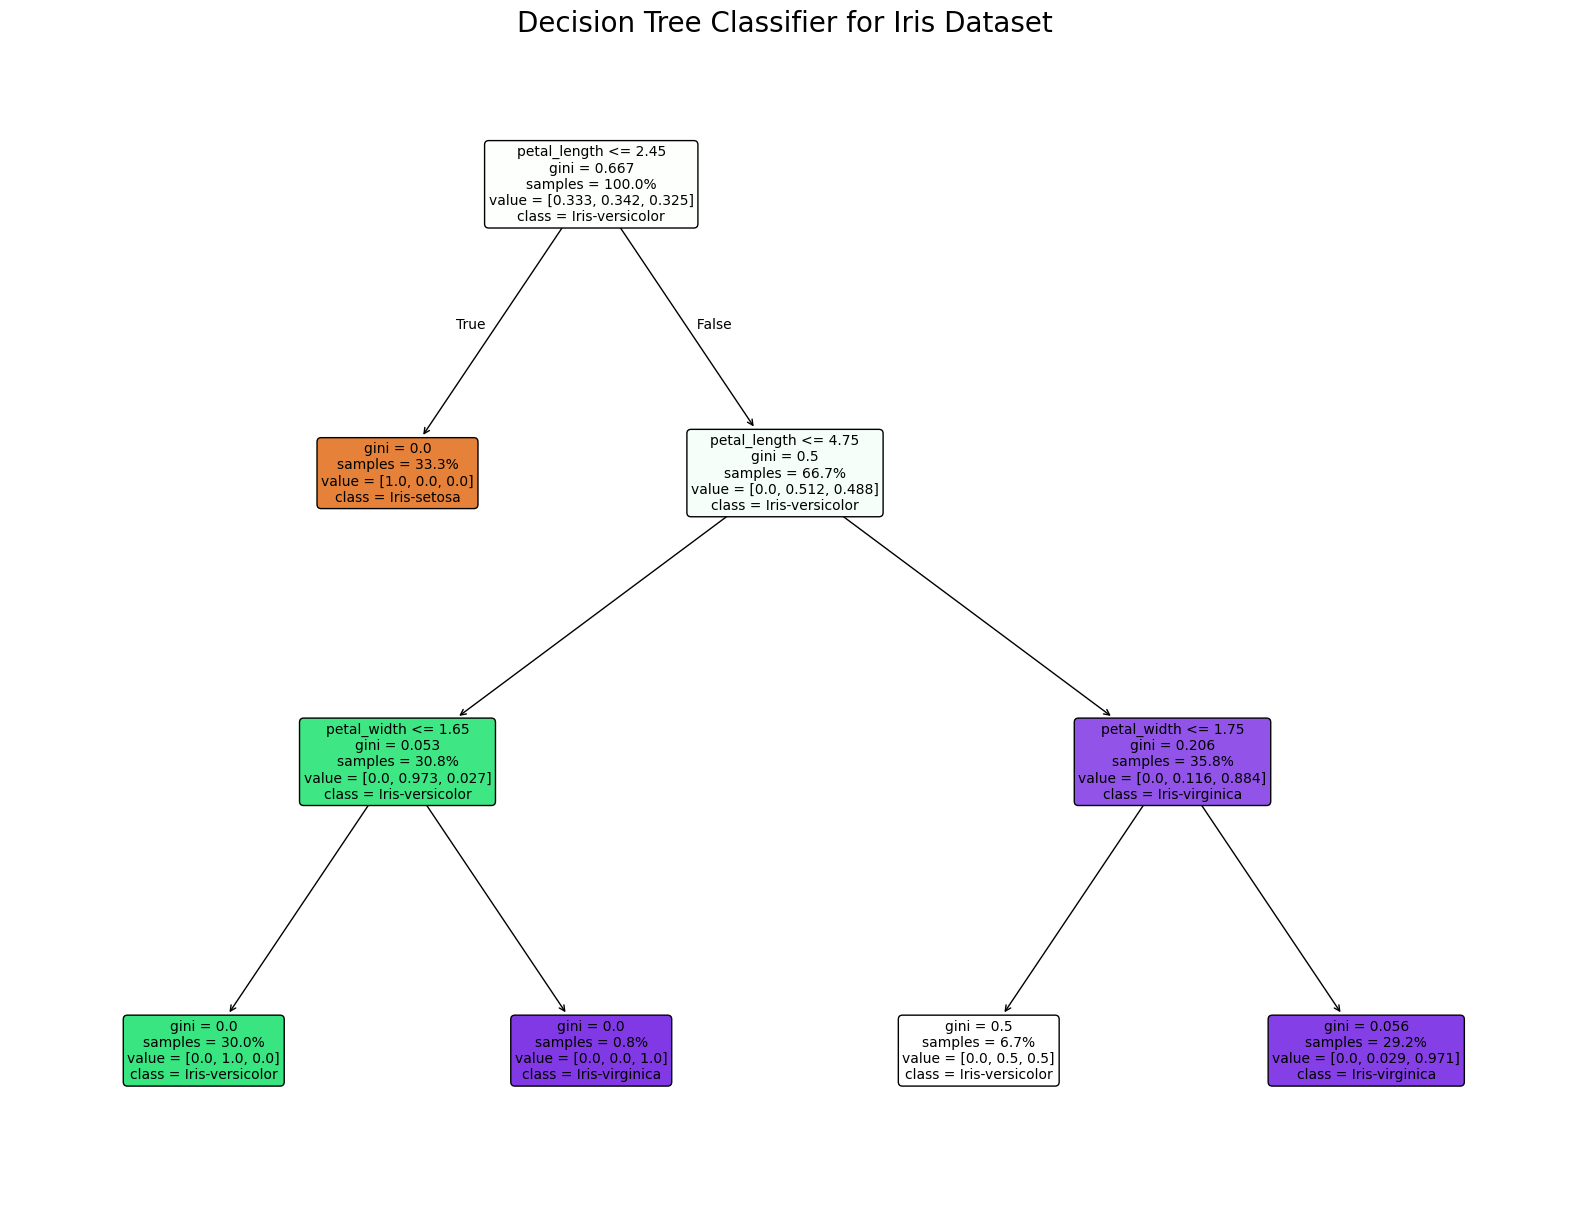

In [ ]:
print("\n5. Plotting and displaying the resulting Decision Tree:")

plt.figure(figsize=(20, 15))
plot_tree(dtc,
          feature_names=X.columns.tolist(),
          class_names=dtc.classes_.tolist(),
          filled=True,
          rounded=True,
          proportion=True,
          fontsize=10)
plt.title('Decision Tree Classifier for Iris Dataset', fontsize=20)
plt.show()